In [1]:
# ================================================
# NOTEBOOK 3 — MODELING & EVALUATION
# SaaS Churn Prediction Project
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (roc_auc_score, classification_report,
                             ConfusionMatrixDisplay, roc_curve)
from lightgbm import LGBMClassifier
import shap

print("✅ Libraries loaded!")

✅ Libraries loaded!


In [2]:
# ================================================
# STEP 1 — LOAD PROCESSED DATA
# ================================================

X_train = pd.read_csv(r'C:\Users\shriv\Documents\churn_prediction\data\processed\X_train.csv')
X_test  = pd.read_csv(r'C:\Users\shriv\Documents\churn_prediction\data\processed\X_test.csv')
y_train = pd.read_csv(r'C:\Users\shriv\Documents\churn_prediction\data\processed\y_train.csv').squeeze()
y_test  = pd.read_csv(r'C:\Users\shriv\Documents\churn_prediction\data\processed\y_test.csv').squeeze()

print("✅ Data loaded!")
print(f"   X_train: {X_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test:  {y_test.shape}")

✅ Data loaded!
   X_train: (8260, 30)
   X_test:  (1407, 30)
   y_train: (8260,)
   y_test:  (1407,)


In [3]:
# ================================================
# STEP 2 — LOAD BEST MODEL
# ================================================

with open(r'C:\Users\shriv\Documents\churn_prediction\models\lgbm_churn_tuned.pkl', 'rb') as f:
    model = pickle.load(f)

# Make predictions
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

auc = roc_auc_score(y_test, y_proba)

print("✅ Model loaded!")
print(f"   Model type: {type(model).__name__}")
print(f"   AUC-ROC Score: {auc:.4f}")

✅ Model loaded!
   Model type: LGBMClassifier
   AUC-ROC Score: 0.8290


=== Classification Report ===

              precision    recall  f1-score   support

        Stay       0.88      0.79      0.83      1033
       Churn       0.55      0.70      0.61       374

    accuracy                           0.77      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.77      0.77      1407



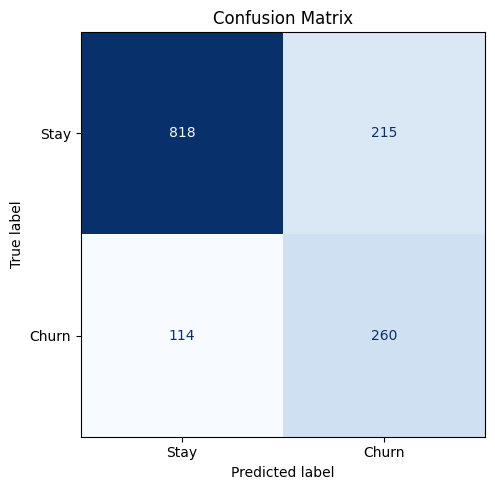


📊 In plain english:
   ✅ Correctly predicted STAY:  818
   ✅ Correctly predicted CHURN: 260
   ❌ False alarms:              215
   ❌ Missed churners:           114


In [4]:
# ================================================
# STEP 3 — CLASSIFICATION REPORT
# ================================================

print("=== Classification Report ===\n")
print(classification_report(y_test, y_pred, 
                             target_names=['Stay', 'Churn']))

# Confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Stay', 'Churn'],
    colorbar=False,
    cmap='Blues',
    ax=ax
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

# Plain english explanation
tn = ((y_test == 0) & (y_pred == 0)).sum()
tp = ((y_test == 1) & (y_pred == 1)).sum()
fp = ((y_test == 0) & (y_pred == 1)).sum()
fn = ((y_test == 1) & (y_pred == 0)).sum()

print(f"\n📊 In plain english:")
print(f"   ✅ Correctly predicted STAY:  {tn}")
print(f"   ✅ Correctly predicted CHURN: {tp}")
print(f"   ❌ False alarms:              {fp}")
print(f"   ❌ Missed churners:           {fn}")

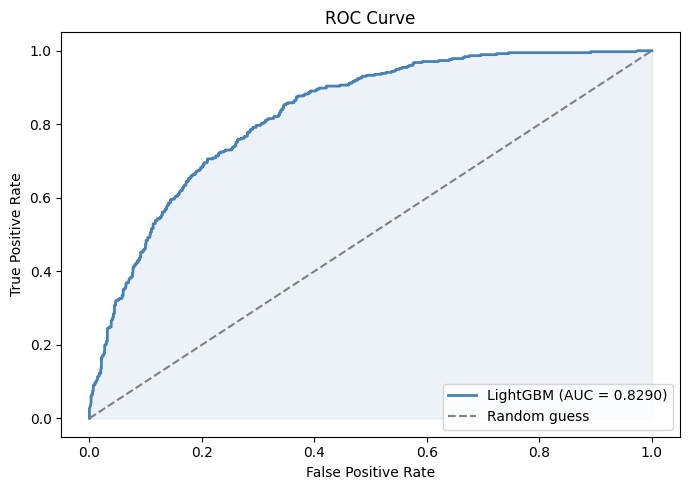

📈 The closer the curve is to the top-left corner,
   the better the model is at predicting churn!


In [5]:
# ================================================
# STEP 4 — ROC CURVE
# ================================================

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='steelblue', linewidth=2,
         label=f'LightGBM (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--',
         label='Random guess')
plt.fill_between(fpr, tpr, alpha=0.1, color='steelblue')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print("📈 The closer the curve is to the top-left corner,")
print("   the better the model is at predicting churn!")

Calculating SHAP values (takes ~30 seconds)...

📊 Top features driving churn:


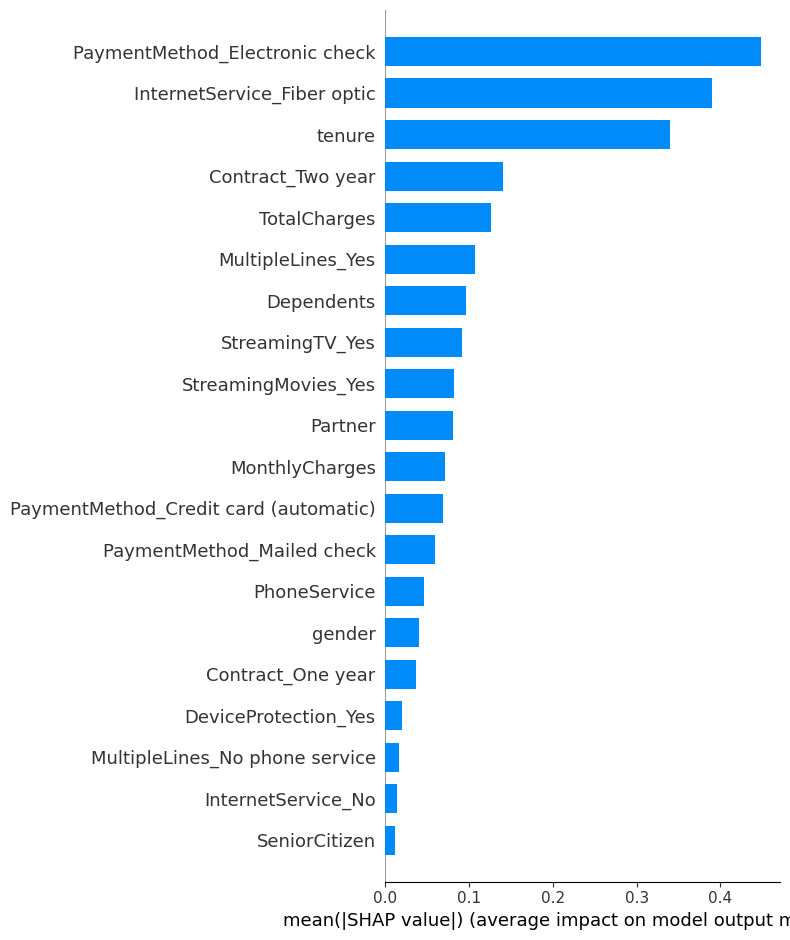

In [6]:
# ================================================
# STEP 5 — FEATURE IMPORTANCE WITH SHAP
# ================================================

print("Calculating SHAP values (takes ~30 seconds)...")

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Plot 1 - Top features bar chart
print("\n📊 Top features driving churn:")
shap.summary_plot(shap_values, X_test, 
                  plot_type='bar',
                  show=True)

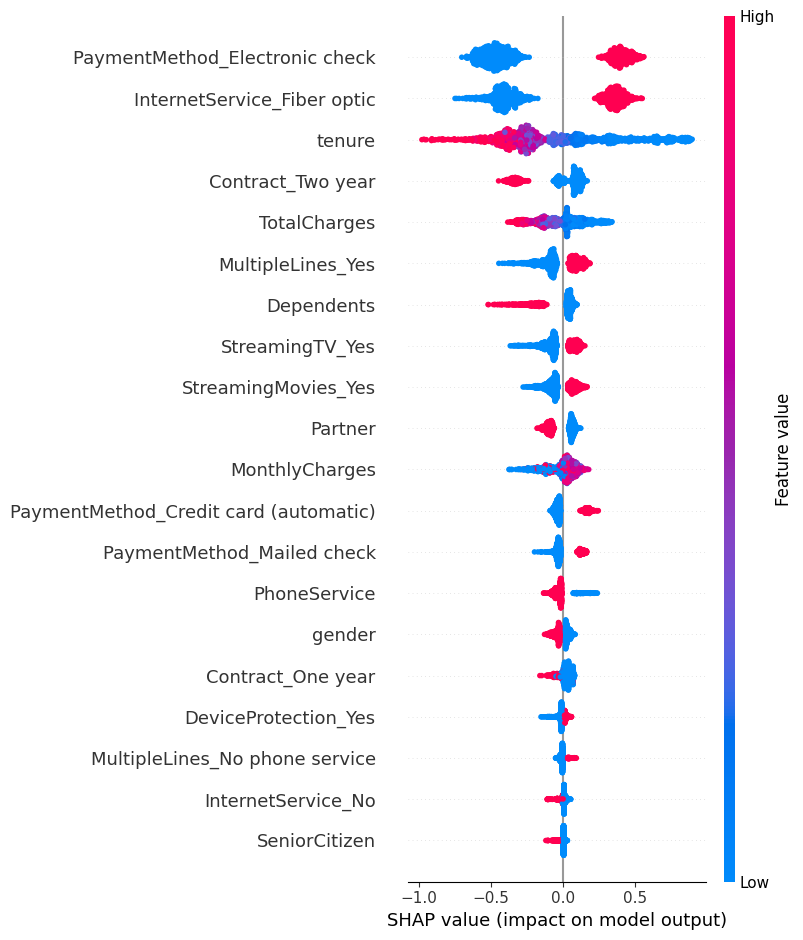


📊 How to read this chart:
   🔴 Red dots  = high value of that feature
   🔵 Blue dots = low value of that feature
   ➡️  Right side = pushes customer toward CHURN
   ⬅️  Left side  = pushes customer toward STAYING


In [7]:
# ================================================
# STEP 6 — SHAP BEESWARM PLOT
# ================================================

# This shows HOW each feature affects churn
# Red = high value, Blue = low value
# Right side = pushes toward churn
# Left side = pushes toward staying

shap.summary_plot(shap_values, X_test, show=True)

print("\n📊 How to read this chart:")
print("   🔴 Red dots  = high value of that feature")
print("   🔵 Blue dots = low value of that feature")
print("   ➡️  Right side = pushes customer toward CHURN")
print("   ⬅️  Left side  = pushes customer toward STAYING")

📋 Explaining prediction for customer #984
   Churn probability: 84.7%
   Actual outcome:    Churned

   Customer details:
   Tenure:          3 months
   Monthly Charges: $96.60
   Total Charges:   $291.90


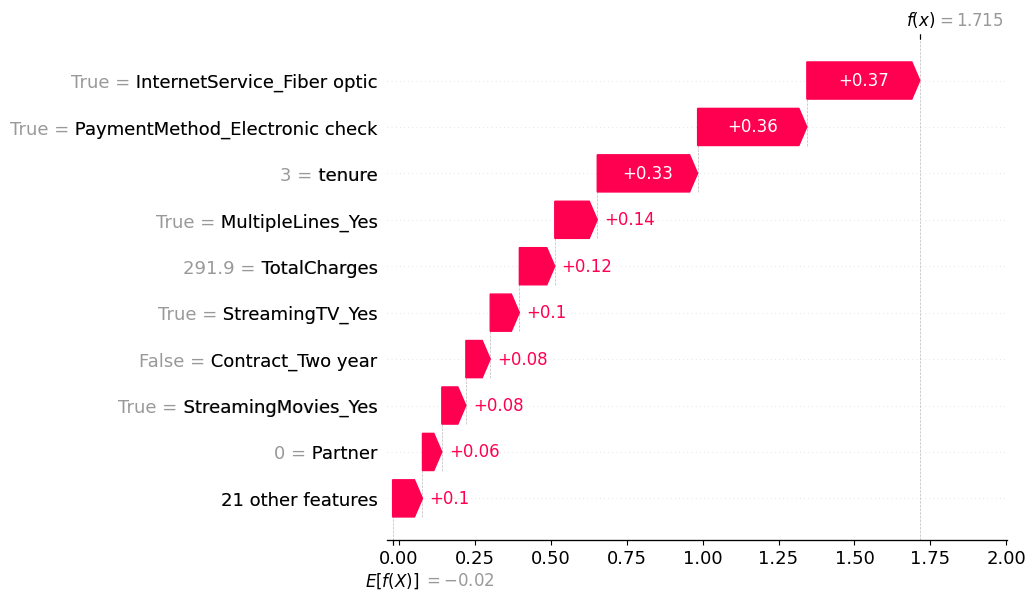

In [8]:
# ================================================
# STEP 7 — SINGLE CUSTOMER EXPLANATION
# ================================================

# Pick a high risk customer from test set
high_risk_idx = y_proba.argmax()

print(f"📋 Explaining prediction for customer #{high_risk_idx}")
print(f"   Churn probability: {y_proba[high_risk_idx]:.1%}")
print(f"   Actual outcome:    {'Churned' if y_test.iloc[high_risk_idx] == 1 else 'Stayed'}")
print(f"\n   Customer details:")
print(f"   Tenure:          {X_test.iloc[high_risk_idx]['tenure']} months")
print(f"   Monthly Charges: ${X_test.iloc[high_risk_idx]['MonthlyCharges']:.2f}")
print(f"   Total Charges:   ${X_test.iloc[high_risk_idx]['TotalCharges']:.2f}")

# Waterfall plot showing why this customer is high risk
shap.plots.waterfall(explainer(X_test)[high_risk_idx])

In [9]:
# ================================================
# STEP 8 — FINAL SUMMARY
# ================================================

print("=" * 50)
print("   CHURN PREDICTION MODEL — FINAL SUMMARY")
print("=" * 50)

print(f"""
📊 DATASET
   Total customers:  7032
   Churned:          1858 (26.5%)
   Stayed:           5174 (73.5%)

🤖 MODEL
   Algorithm:        LightGBM (Optuna tuned)
   Training rows:    8244 (after SMOTE)
   Testing rows:     1407

📈 PERFORMANCE
   AUC-ROC Score:    {auc:.4f}
   
   Correctly predicted STAY:  {tn}
   Correctly predicted CHURN: {tp}
   False alarms:              {fp}
   Missed churners:           {fn}

🔍 TOP CHURN DRIVERS
   1. Payment method
   2. Internet service
   3. Tenure

🚀 DEPLOYMENT
   ✅ FastAPI endpoint  → http://127.0.0.1:8000/docs
   ✅ Dashboard         → http://localhost:8501
""")

print("=" * 50)
print("   PROJECT COMPLETE! 🎉")
print("=" * 50)

   CHURN PREDICTION MODEL — FINAL SUMMARY

📊 DATASET
   Total customers:  7032
   Churned:          1858 (26.5%)
   Stayed:           5174 (73.5%)

🤖 MODEL
   Algorithm:        LightGBM (Optuna tuned)
   Training rows:    8244 (after SMOTE)
   Testing rows:     1407

📈 PERFORMANCE
   AUC-ROC Score:    0.8290

   Correctly predicted STAY:  818
   Correctly predicted CHURN: 260
   False alarms:              215
   Missed churners:           114

🔍 TOP CHURN DRIVERS
   1. Payment method
   2. Internet service
   3. Tenure

🚀 DEPLOYMENT
   ✅ FastAPI endpoint  → http://127.0.0.1:8000/docs
   ✅ Dashboard         → http://localhost:8501

   PROJECT COMPLETE! 🎉
